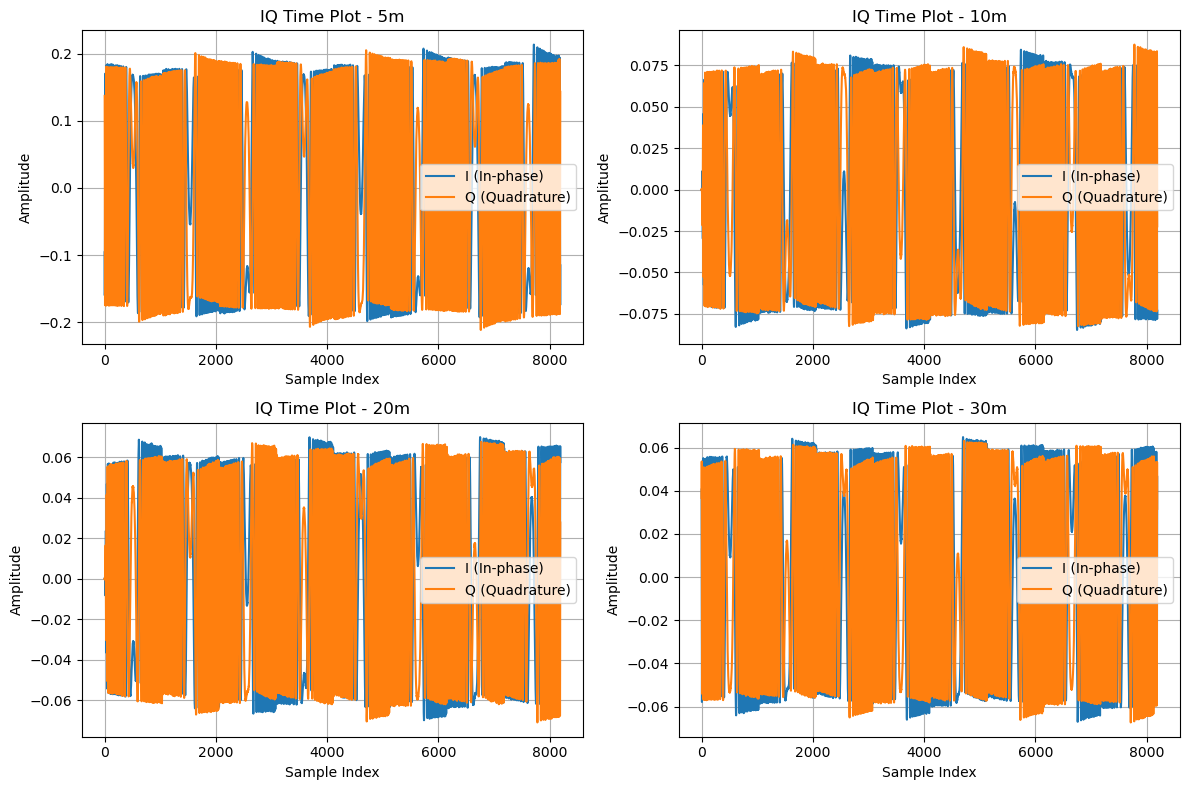

In [1]:
import numpy as np
import matplotlib.pyplot as plt

device= 20
frame = 0
distance = 10

D20_5m=np.fromfile(rf"/home/etude/Music/final/InsideOneByOne/5m550frames/device{device}/frame_{frame}.sigmf-data", dtype=np.complex64)
D20_10m=np.fromfile(rf"/home/etude/Music/final/InsideOneByOne/10m550frames/device{device}/frame_{frame}.sigmf-data", dtype=np.complex64)
D20_20m=np.fromfile(rf"/home/etude/Music/final/InsideOneByOne/20m550frames/device{device}/frame_{frame}.sigmf-data", dtype=np.complex64)
D20_30m=np.fromfile(rf"/home/etude/Music/final/InsideOneByOne/30m550frames/device{device}/frame_{frame}.sigmf-data", dtype=np.complex64)


D2_5m=D20_5m[0:8192]  #  just 8 upchirps
D2_10m=D20_10m[0:8192]
D2_20m=D20_20m[0:8192]
D2_30m=D20_30m[0:8192]

frames = {
    "5m": D2_5m,
    "10m": D2_10m,
    "20m": D2_20m,
    "30m": D2_30m
}
# time domain IQ plot at multiple distances 

plt.figure(figsize=(12, 8))

for i, (dist, data) in enumerate(frames.items(), 1):
    plt.subplot(2, 2, i)
    plt.plot(np.real(data), label="I (In-phase)")
    plt.plot(np.imag(data), label="Q (Quadrature)")
    plt.title(f"IQ Time Plot - {dist}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.savefig("test.svg")
plt.show()


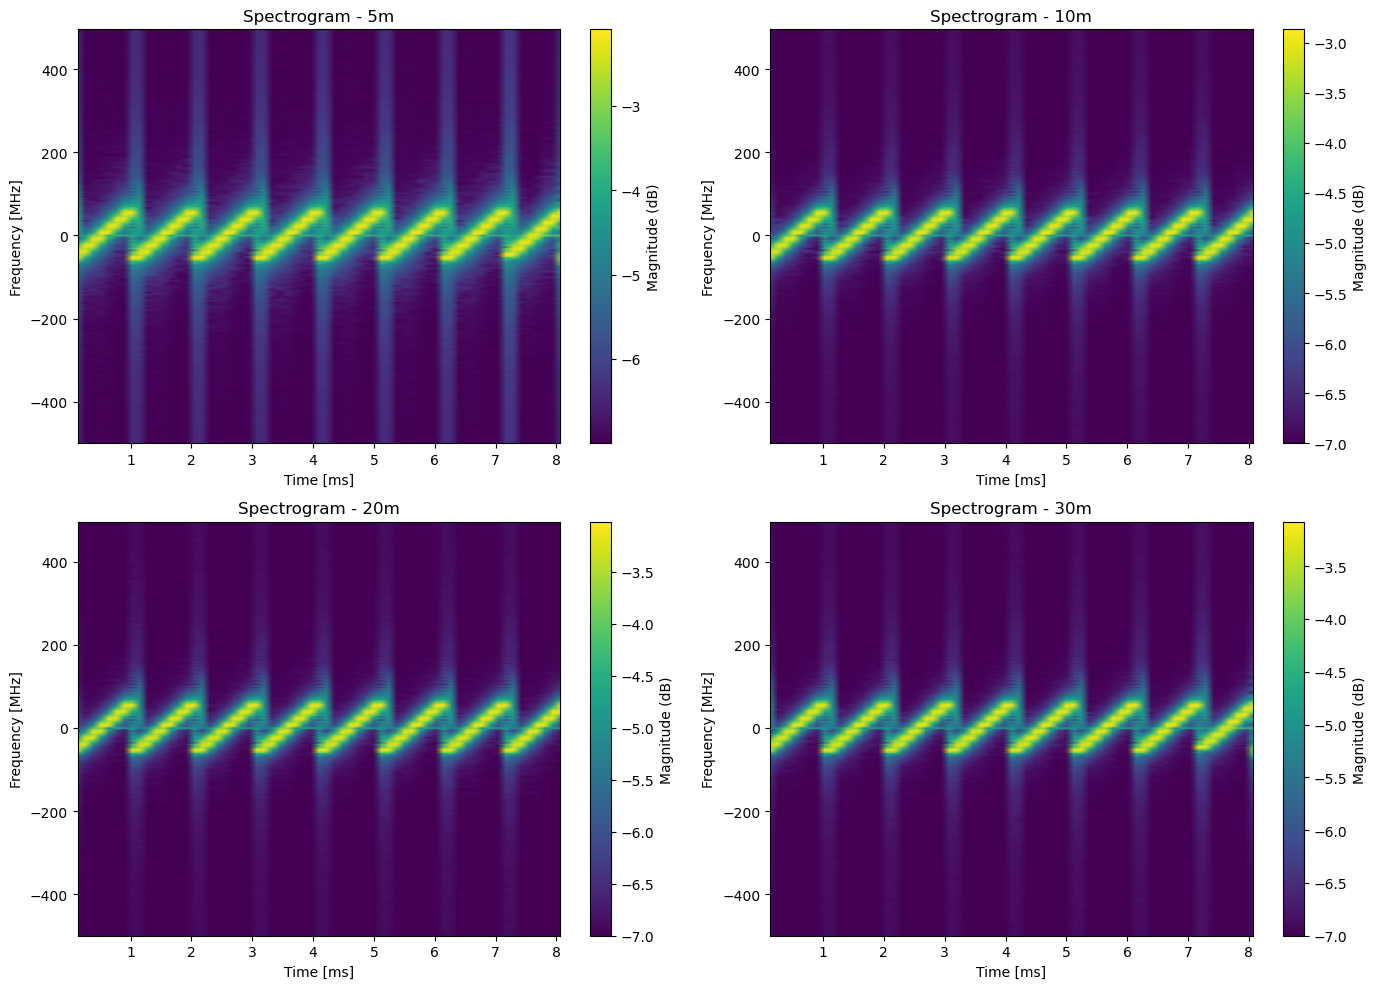

In [2]:

#spectrogram using signal library of Scipy

from scipy import signal 


plt.figure(figsize=(14, 10))

for i, (dist, data) in enumerate(frames.items(), 1):
    f, t, spec = signal.stft(data[0:8192],
                             window='boxcar',    
                             nperseg=256,
                             noverlap=128,
                             nfft=256,
                             return_onesided=False,
                             padded=False,
                             boundary=None)

    f_shifted = np.fft.fftshift(f, axes=0)
    spec = np.fft.fftshift(spec, axes=0)
    spec_amp = np.log10(np.abs(spec) ** 2 + 1e-7)  # avoid log(0)

    plt.subplot(2, 2, i)
    plt.pcolormesh(t/1e3, f_shifted*1e3, spec_amp, shading='gouraud')
    plt.ylabel('Frequency [MHz]')
    plt.xlabel('Time [ms]')
    plt.title(f"Spectrogram - {dist}")
    plt.colorbar(label='Magnitude (dB)')

plt.tight_layout()
plt.savefig("test.png")
plt.show()

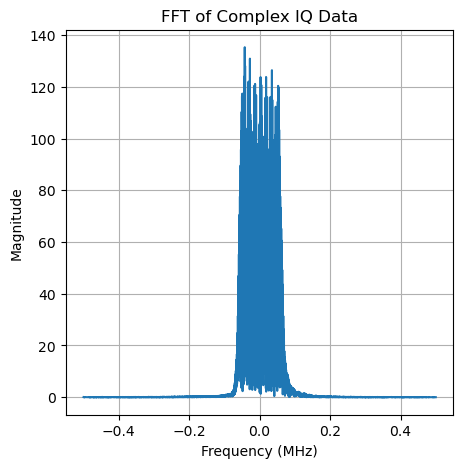

In [3]:
# Compute the FFT of the data

sampling_rate=1e6

fft_data = np.fft.fftshift(np.fft.fft(D2_5m))  
fft_magnitude = np.abs(fft_data)
n_samples = len(D2_5m)
frequencies = np.fft.fftfreq(n_samples, d=1/sampling_rate) 
frequencies = np.fft.fftshift(frequencies)   #//shifting to center the spectrum

plt.figure(figsize=(5,5))
plt.plot(frequencies/1e6, fft_magnitude)
plt.title("FFT of Complex IQ Data")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()



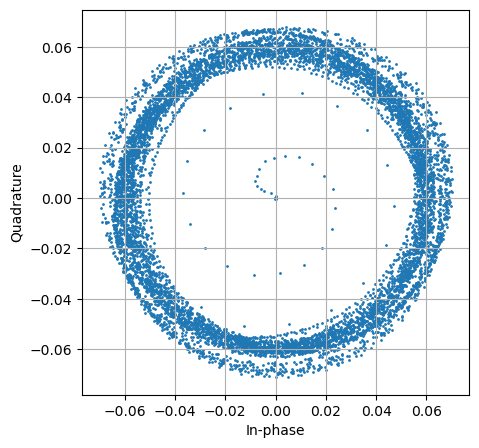

In [4]:
# Plotting constellation diagrams for the provided frames
plt.figure(figsize=(5,5))
plt.scatter(np.real(D2_20m), np.imag(D2_20m), s=1)
plt.title('')
plt.xlabel('In-phase')
plt.ylabel('Quadrature')
plt.grid(True)
plt.show()



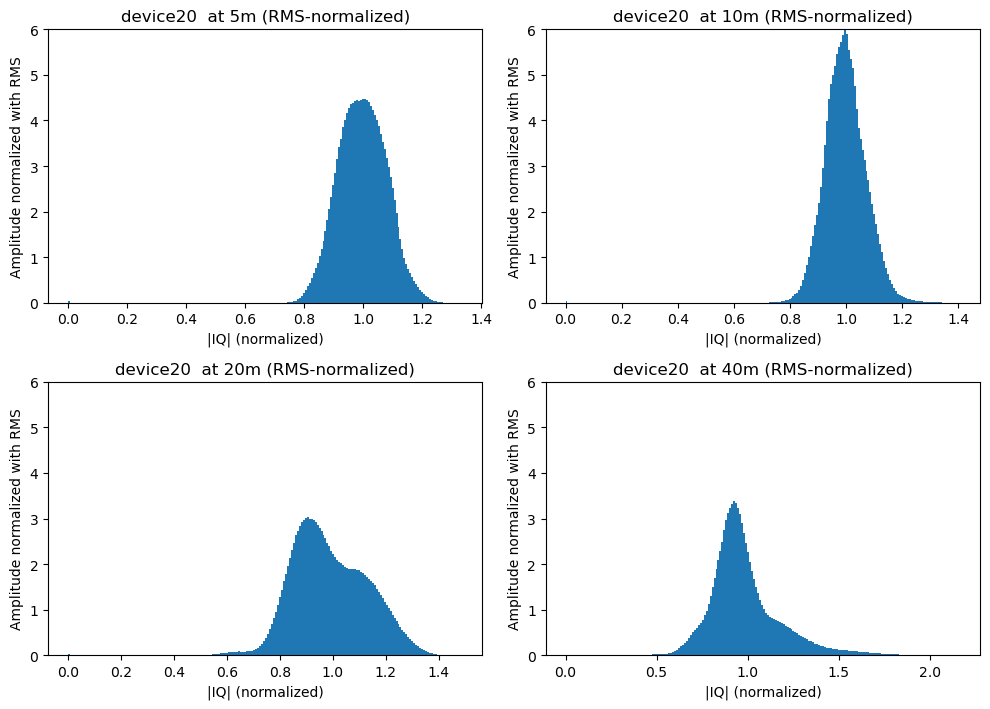

In [2]:
import os, glob, math
import numpy as np
import matplotlib.pyplot as plt

def load_sigmf(path: str) -> np.ndarray:
    iq = np.fromfile(path, dtype=np.complex64)
    return iq


#get frames per device sorted 
def gather_per_device(root: str, device_glob="device*", frame_pattern="*.sigmf-data"):
    per_dev = {}    # store per device data 
    device_dirs = sorted(glob.glob(os.path.join(root, device_glob)))   #look for device directories 
    if not device_dirs:
        raise FileNotFoundError(f"No device dirs like '{device_glob}' in {root}")   

    for d in device_dirs:
        dev = os.path.basename(d.rstrip("/"))
        files = sorted(glob.glob(os.path.join(d, frame_pattern)))   #look for sigmf-data files in folders
        if not files:
            print(f"{dev}: no frames found, skipping")    #sanity check if no data found
            continue

        chunks = []
        total = 0
        for fp in files:
            x = load_sigmf(fp)
            chunks.append(x.astype(np.complex64, copy=False))
            total += x.size
        per_dev[dev] = np.concatenate(chunks, axis=0)
        print(f"{dev}: concatenated {len(files)} frames")
    return per_dev

# get rms  
def rms_complex(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(np.abs(x) ** 2)))
# ---------- Plot ----------
def plot_amp_hist_per_device(per_dev,distances, bins=200, save_path="amp_hist_per_device.png"):
    n = len(per_dev)   #get device number
    if n == 0:
        raise RuntimeError("No devices to plot")    #sanity check

    cols = min(3, n)                 # figure up to 3 columns
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.6*rows), squeeze=False)
    axes = axes.ravel()

    for i, (dev, x) in enumerate(sorted(per_dev.items())):
        ax = axes[i]
        r = rms_complex(x)
        x_norm = x / (r + 1e-12)     # RMS normalization per device
        amp = np.abs(x_norm)

        ax.hist(amp, bins=bins, density=True)
        ax.set_title(f"{dev}  (RMS-normalized)")
        ax.set_xlabel("|IQ| (normalized)")
        ax.set_ylabel("PDF")

    # hide any unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    #plt.savefig(save_path, dpi=150)  --> if you want to save figure
    #print(f"[SAVE] {save_path}")
    plt.show()

def plot_amp_hist_of_dev(root, dev,distances, bins=200, save_path="amp_hist_per_device.png"):
    n = len(per_dev)   #get device number
    if n == 0:
        raise RuntimeError("No devices to plot")    #sanity check

    cols = min(2, n)                 # figure up to 3 columns
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.6*rows), squeeze=False)
    axes = axes.ravel()

    for i, (dev, x) in enumerate(per_dev.items()):
        ax = axes[i]
        r = rms_complex(x)
        x_norm = x / (r + 1e-12)     # RMS normalization per device
        amp = np.abs(x_norm)

        ax.hist(amp, bins=bins, density=True)
        ax.set_title(f"{dev[0:8]}  at {dev[8:10].split("m")[0]}m (RMS-normalized)")
        ax.set_xlabel("|IQ| (normalized)")
        ax.set_ylim(0,6)
        ax.set_ylabel("Amplitude normalized with RMS")

    # hide any unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    #plt.savefig(save_path, dpi=150)  --> if you want to save figure
    #print(f"[SAVE] {save_path}")
    plt.savefig("histo.png")
    plt.show()

#get frames per device sorted 
def gather_per_distance(root: str,distances, device_glob="device20*", frame_pattern="*.sigmf-data"):
    per_dev = {}    # store per device data 

    for distance in distances:
        device_dirs = glob.glob(os.path.join(root, f"{distance}/{device_glob}"))   #look for device directories 
        if not device_dirs:
            raise FileNotFoundError(f"No device dirs like '{distance}/{device_glob}' in {root}")   
        for d in device_dirs:
            dev = os.path.basename(d.rstrip("/")) + distance
            files = glob.glob(os.path.join(d, frame_pattern))   #look for sigmf-data files in folders
            if not files:
                print(f"{dev}: no frames found, skipping")    #sanity check if no data found
                continue
    
            chunks = []
            total = 0
            for fp in files:
                x = load_sigmf(fp)
                chunks.append(x.astype(np.complex64, copy=False))
                total += x.size
            per_dev[dev] = np.concatenate(chunks, axis=0)
    return per_dev

    
# ---------- Run ---------- Indoor Sports Hall DAta
if __name__ == "__main__":
    distances = ["5m550frames","10m550frames","20m550frames","40m550frames"]
    ROOT = r"/home/etude/Music/final/InsideOneByOne"
    per_dev = gather_per_distance(ROOT, distances)
    plot_amp_hist_of_dev(ROOT, 20, distances, bins=200, save_path="amp_hist_per_device.png")
